# Prepare data for training Cell2net model

In this tutorial, we will prepare K562 multiome data for training Cell2Net models. 
This involves creating metacells, adding peak sequences, finding TF binding sites within
peaks, and linking peaks and TFs to genes through regulatory relationships.

## Why Metacells?

Single-cell data is inherently noisy due to:
- **Technical noise** from low capture efficiency and dropout events
- **Biological heterogeneity** within cell populations
- **Computational constraints** when training on thousands of individual cells

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import numpy as np
import mudata as md
import cell2net as cn
import scanpy as sc

md.set_options(pull_on_update=False)

## Set Input and Output Paths

We define the paths for input data and output directory. The input data comes from the processed K562 multiome dataset.

In [2]:
input_data = "../../../../results/37_K562_10x_multiome/05_create_mdata/mdata.h5mu"
out_dir = "./02_prepare_data"

os.makedirs(out_dir, exist_ok=True)

### Load Multiome Dataset

Load the preprocessed K562 multiome data containing both RNA-seq and ATAC-seq measurements from the same cells.

In [3]:
mdata = md.read_h5mu(input_data)

mdata

MuData object with n_obs × n_vars = 6508 × 151699
  obs:	'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	6508 x 15735
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg'
      obsm:	'X_pca', 'X_umap'
      layers:	'counts'
    atac:	6508 x 135964
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      obsm:	'X_umap'
      layers:	'counts'

## Create Metacells

Now we'll create metacells by aggregating similar single cells. This process:

### Parameters:
- **n_metacells=500**: Target number of metacells to create
- **use_rep="X_pca"**: Use PCA space for finding similar cells  
- **sampling="random"**: Random sampling strategy for scalability
- **n_neighbors=50**: Number of similar cells to aggregate per metacell

### Benefits:
- **Noise reduction**: Averaging reduces technical noise and dropout effects
- **Computational efficiency**: 500 metacells vs. thousands of single cells
- **Signal preservation**: Maintains biological heterogeneity while improving SNR
- **Scalable training**: Enables efficient model training on representative data

In [4]:
mdata_bulk = cn.tl.get_metacells(mdata, n_metacells=500, use_rep="X_pca", 
                                 sampling="random", n_neighbors=50)

2025-11-20 02:13:46 INFO     Total number of metacells to create: 500


2025-11-20 02:13:46 INFO     No groupby provided, using all cells


2025-11-20 02:13:46 INFO     Create KNN graph with X_pca and 50 neighbors


2025-11-20 02:15:53 INFO     Done


Let's examine the structure of our metacell dataset. Notice how the number of observations has been reduced from thousands of single cells to 500 representative metacells.

In [5]:
mdata_bulk

MuData object with n_obs × n_vars = 500 × 151699
  obs:	'total_counts_rna', 'total_counts_atac', 'total_counts_rna_log', 'total_counts_atac_log'
  2 modalities
    rna:	500 x 15735
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'genes', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      layers:	'counts'
    atac:	500 x 135964
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'BlacklistRatio', 'DoubletScore', 'DoubletEnrichment', 'ReadsInPeaks', 'FRIP', 'nCount_ATAC', 'nFeature_ATAC', 'percent.mt', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
      var:	'peaks', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	'counts'

### Update Metacell Metadata

We need to properly organize the metadata for our metacells by:

1. **Separating modality-specific counts** - RNA and ATAC total counts
2. **Adding log-transformed counts** - For use as covariates in modeling
3. **Combining into unified metadata** - Single observation table for both modalities

This metadata will be used later as covariates to account for technical variation in Cell2Net models.

In [6]:
# update total counts for meta cells
df_obs_rna = mdata_bulk['rna'].obs[['total_counts']]
df_obs_rna = df_obs_rna.rename(columns={'total_counts': 'total_counts_rna'})

df_obs_atac = mdata_bulk['atac'].obs[['total_counts']]
df_obs_atac = df_obs_atac.rename(columns={'total_counts': 'total_counts_atac'})

df_obs = pd.concat([df_obs_rna, df_obs_atac], axis=1)

mdata_bulk.obs = df_obs.copy()

mdata_bulk.obs['total_counts_rna_log'] = np.log10(mdata_bulk.obs['total_counts_rna'])
mdata_bulk.obs['total_counts_atac_log'] = np.log10(mdata_bulk.obs['total_counts_atac'])

### Compute Embeddings for Metacells

Let's compute UMAP embeddings to visualize the diversity captured in our metacells:

1. **Normalize RNA counts** - Standard total-count normalization
2. **Principal Component Analysis** - Dimensionality reduction to 15 components  
3. **Nearest neighbor graph** - Build connectivity between similar metacells
4. **UMAP embedding** - 2D visualization of metacell relationships

This helps us verify that metacells preserve the biological diversity present in the original single-cell data.

In [7]:
# visualize metacells
sc.pp.normalize_total(mdata_bulk['rna'])
sc.tl.pca(mdata_bulk['rna'], n_comps=15, use_highly_variable=True)
sc.pp.neighbors(mdata_bulk['rna'])
sc.tl.umap(mdata_bulk['rna'])

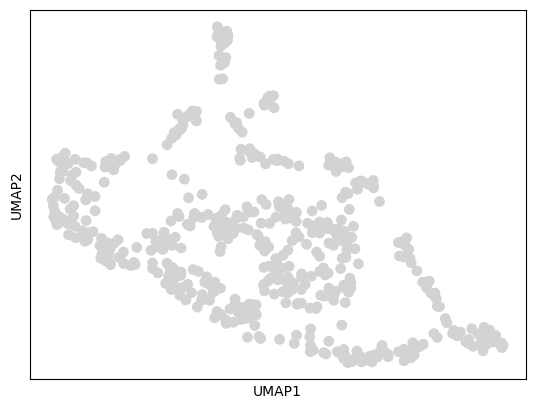

In [8]:
sc.pl.umap(mdata_bulk['rna'])

The UMAP plot shows the distribution of our 500 metacells in 2D space. Good metacell generation should preserve the major cell type groups and transitions present in the original data.

## Add Genomic Annotations

Now we'll enrich our dataset with essential genomic information needed for Cell2Net modeling:

### Key Annotations:
1. **Gene TSS coordinates** - Transcription start sites of genes for regulatory modeling
2. **Peak sequences** - 256bp DNA sequences around ATAC peak summits  
3. **DNA sequences** - Extracted from reference genome for sequence analysis

This genomic context is crucial for understanding regulatory relationships between chromatin accessibility and gene expression.

In [9]:
cn.pp.add_gene_tss_coord(mdata_bulk, gene_gtf='../../../../data/refdata-gex-GRCh38-2020-A/genes/genes.gtf.gz')
cn.pp.add_peaks(mdata_bulk, mod_name='atac', peak_len=256)
cn.pp.add_dna_sequence(mdata_bulk, ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa')

2025-11-20 02:15:55 INFO     Adding gene TSS coordinates from ../../../../data/refdata-gex-GRCh38-2020-A/genes/genes.gtf.gz to rna modality.


Fetching sequences:   0%|                                                                                                                                                                                  | 0/135964 [00:00<?, ?it/s]

Fetching sequences:  18%|█████████████████████████████▌                                                                                                                                    | 24794/135964 [00:00<00:00, 247882.91it/s]

Fetching sequences:  36%|███████████████████████████████████████████████████████████                                                                                                       | 49583/135964 [00:00<00:00, 237794.52it/s]

Fetching sequences:  54%|███████████████████████████████████████████████████████████████████████████████████████▉                                                                          | 73825/135964 [00:00<00:00, 239833.73it/s]

Fetching sequences:  72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                             | 97829/135964 [00:00<00:00, 229676.88it/s]

Fetching sequences:  93%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍           | 126245/135964 [00:00<00:00, 248602.47it/s]

Fetching sequences: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 135964/135964 [00:00<00:00, 244752.83it/s]

## Load Transcription Factor Motifs

We'll load transcription factor (TF) binding motifs from the JASPAR2024 database. 
These position weight matrices (PWMs) represent the DNA binding preferences of different transcription factors.

In [10]:
motifs = cn.pp.get_tf_motifs(database='JASPAR2024')

2025-11-20 02:16:07 INFO     Number of motifs fetched: 879


### Filter Motifs by Expressed Genes

We filter the motif collection to only include transcription factors that are expressed in our K562 dataset. This reduces computational complexity and focuses on biologically relevant TFs.

**Rationale**: Only TFs that are expressed can potentially regulate target genes in this cell type.

In [11]:
cn.pp.filter_motifs_by_genes(motifs, mdata_bulk)

2025-11-20 02:16:07 INFO     Number of motifs overlapped with genes: 416


### Scan for Motif Matches

Now we scan all ATAC peak sequences for TF binding motif matches using a stringent p-value threshold (1e-04).

**Process**:
1. **Sequence scanning** - Search each 256bp peak sequence for motif matches
2. **Statistical scoring** - Calculate p-values for potential binding sites  
3. **Threshold filtering** - Keep only high-confidence matches (p < 1e-04)
4. **Position recording** - Store exact locations of predicted binding sites

This creates a comprehensive map of where transcription factors likely bind within our accessible chromatin regions.

In [12]:
cn.pp.match_motif(mdata_bulk, motifs, p_value=1e-04)

2025-11-20 02:16:07 INFO     Matching TF motifs


Scanning motifs:   0%|                                                                                                                                                                                     | 0/135964 [00:00<?, ?it/s]

Scanning motifs:   0%|                                                                                                                                                                           | 41/135964 [00:00<05:35, 405.26it/s]

Scanning motifs:   0%|                                                                                                                                                                           | 82/135964 [00:00<05:39, 399.80it/s]

Scanning motifs:   0%|▏                                                                                                                                                                         | 124/135964 [00:00<05:33, 407.57it/s]

...

Scanning motifs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 135878/135964 [05:35<00:00, 416.39it/s]

Scanning motifs: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 135921/135964 [05:35<00:00, 417.93it/s]

Scanning motifs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 135964/135964 [05:35<00:00, 419.24it/s]

Scanning motifs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 135964/135964 [05:35<00:00, 405.49it/s]

2025-11-20 02:21:57 INFO     Motif matching is done!


## Link Regulatory Elements

Now we establish regulatory connections between chromatin accessibility and gene expression.

### Peak-to-Gene Linking

This critical step identifies which ATAC peaks potentially regulate which genes:

**Parameters**:
- **min_n_peaks=1**: Minimum peaks required per gene for modeling
- **highly_variable=True**: Focus on genes with variable expression
- **gene_name_col="genes"**: Use gene symbols for identification

**Method**: Uses genomic distance, chromatin accessibility correlation, and other features to predict regulatory relationships between peaks and genes.

In [13]:
cn.pp.peak_to_gene(mdata_bulk,
                   ref_fasta='../../../../data/refdata-gex-GRCh38-2020-A/fasta/genome.fa',
                   min_n_peaks=1,
                   highly_variable=True,
                   gene_name_col="genes",
                   inplace=True)

2025-11-20 02:21:57 INFO     Fetching TSS coordinates


2025-11-20 02:21:57 INFO     Using highly variable genes


2025-11-20 02:21:57 INFO     Number of genes: 1644


2025-11-20 02:21:57 INFO     Number of peaks: 135964


2025-11-20 02:21:57 INFO     Linking genes to nearby peaks


...

Linking genes to peaks: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍| 1639/1644 [00:40<00:00, 40.72it/s]

Linking genes to peaks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1644/1644 [00:40<00:00, 40.69it/s]

Linking genes to peaks: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1644/1644 [00:40<00:00, 40.71it/s]

2025-11-20 02:22:38 INFO     Number of genes that have at least 1 peaks: 1608


2025-11-20 02:22:38 INFO     Identified 128324 potential peak-to-gene links


### TF-to-Gene Relationships

Finally, we establish connections between transcription factors and their potential target genes by combining:

1. **Motif matches in peaks** - Where TFs can bind  
2. **Peak-to-gene links** - Which peaks regulate which genes
3. **TF expression** - Which TFs are active in these cells

This creates a comprehensive regulatory network showing how TFs → peaks → genes, which is the foundation for Cell2Net modeling.

In [14]:
cn.pp.tf_to_gene(mdata_bulk)

2025-11-20 02:22:38 INFO     Linking potential TFs for each gene


Finding TFs:   0%|                                                                                                                                                                                           | 0/1608 [00:00<?, ?it/s]

Finding TFs:   0%|                                                                                                                                                                                   | 1/1608 [00:00<02:41,  9.93it/s]

Finding TFs:   0%|▎                                                                                                                                                                                  | 3/1608 [00:00<01:49, 14.69it/s]

Finding TFs:   0%|▋                                                                                                                                                                                  | 6/1608 [00:00<01:19, 20.22it/s]

...

Finding TFs:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋  | 1587/1608 [00:41<00:00, 49.70it/s]

Finding TFs:  99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎ | 1593/1608 [00:41<00:00, 51.45it/s]

Finding TFs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 1601/1608 [00:41<00:00, 56.79it/s]

Finding TFs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 1607/1608 [00:41<00:00, 51.06it/s]

Finding TFs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1608/1608 [00:41<00:00, 38.71it/s]

## Save Processed Dataset

We save the fully processed dataset containing:

- **500 metacells** with aggregated RNA/ATAC measurements  
- **Genomic annotations** - Gene coordinates, peak sequences, motif matches
- **Regulatory networks** - Peak-to-gene and TF-to-gene relationships
- **Metadata** - Total counts and other covariates for modeling

This processed dataset is now ready for Cell2Net model training!

In [15]:
mdata_bulk.write_h5mu(f'{out_dir}/mdata.h5mu')

### Export Motif Matches

Additionally, we export the motif match results as a BED file for external analysis or visualization in genome browsers.

**BED format contains**:
- **Chromosome, start, end** - Genomic coordinates of binding sites
- **Motif ID** - Which transcription factor motif matched  
- **Score** - Binding affinity prediction
- **Strand** - DNA strand orientation

This can be loaded into IGV, UCSC Genome Browser, or other tools for visual inspection of predicted TF binding sites.

In [16]:
# save motif match results to a bed file
motif_bed = mdata_bulk['atac'].uns['motif_match']
motif_bed.to_csv(f'{out_dir}/motif_match.bed', sep='\t', index=False, header=False)

## Summary

Excellent! You've successfully prepared a comprehensive dataset for Cell2Net modeling. Here's what we accomplished:

### Data Processing Pipeline
1. ✅ **Metacell Creation** - Reduced 1000s of cells to 500 representative metacells  
2. ✅ **Genomic Annotation** - Added gene coordinates, peak sequences, and DNA context
3. ✅ **Motif Analysis** - Identified TF binding sites in accessible chromatin  
4. ✅ **Regulatory Mapping** - Linked peaks to genes and TFs to targets
5. ✅ **Data Export** - Saved processed dataset and motif matches

### Key Outputs
- **`mdata.h5mu`** - Complete processed multiome dataset ready for modeling
- **`motif_match.bed`** - TF binding site predictions for genome browser visualization
- **Regulatory networks** - Peak→gene and TF→gene relationship maps
- **Quality control** - Verified metacells preserve biological diversity

### Next Steps
With this prepared dataset, you can now:

1. **Train Cell2Net models** - Use the processed metacells for joint RNA-ATAC modeling
2. **Analyze regulatory circuits** - Explore peak-to-gene and TF-to-gene relationships  
3. **Predict perturbations** - Model effects of TF knockdowns or overexpression
4. **Compare cell types** - Use as reference for other cell line comparisons
5. **Interpret mechanisms** - Understand sequence→expression relationships

The dataset contains all the components needed to build interpretable models of gene regulatory networks from multiome data!